<a href="https://colab.research.google.com/github/2xsec/2xsec.github.io/blob/master/04_Transformer_Attention_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Transformer : Attention 연산 실습**

이번 실습에서는 **Transformer 모델**을 배우기에 앞서,  
그 핵심이 되는 **Attention 연산**이 실제로 어떻게 계산되는지 직접 확인해봅니다.

# 0. Colab 환경설정
- colab에서 Google Drive에 접근할 수 있도록 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("[현재 파일 위치]")
!pwd
print("[현재 디렉토리의 파일 확인]")
!ls

Mounted at /content/drive
[현재 파일 위치]
/content
[현재 디렉토리의 파일 확인]
drive  sample_data


**day 1** 폴더로 이동해주세요.

왼쪽의 **폴더** 아이콘을 클릭하면 경로를 쉽게 볼 수 있습니다.

In [ ]:
# 본인 환경에 맞게 경로를 수정하여 사용하세요.
%cd /content/drive/MyDrive/day1
!pwd

/content/drive/.shortcut-targets-by-id/14tWNTY4XR3u9s_HAqwbH1vpIHSLUipBb/day1
/content/drive/.shortcut-targets-by-id/14tWNTY4XR3u9s_HAqwbH1vpIHSLUipBb/day1


# 1. Self-Attention 이해하기

RNN은 입력을 **앞에서부터 순서대로** 읽습니다.  
그래서 시퀀스 데이터를 다룰 수 있다는 장점이 있지만, 다음과 같은 한계도 있습니다.

- 문장이 길어질수록 먼 과거 정보가 약해질 수 있음
- 현재 단어가 문장 전체 중 **어디를 중요하게 봐야 하는지** 직접 드러나지 않음
- 순차적으로 계산하므로 병렬화가 불리함

Attention은 아주 간단하게 말하면,

> **`현재 토큰`이, 입력 시퀀스의 `다른 토큰들을 얼마나 참고할지` 각각 계산하는 방법**

입니다.

이번 실습에서 다루는 것은 **Self-attention**입니다.  
**Self-attention**은 문장 안의 각 토큰이, 같은 문장에 있는 다른 토큰들을 참고해 자신의 표현을 새롭게 만드는 방식입니다.

이번 실습에서는 아래 문장을 예시로 사용합니다.

- `The movie was not good`

## 1-0. 예시 문장 토큰화

In [ ]:
# RNN 실습에서 사용해봤던 토크나이저를 사용합니다.
from utils_rnn import simple_tokenizer

###### [실습] 문장을 토큰화합니다. ######
sentence = "The movie was not good"
tokens = simple_tokenizer(sentence)

print("sentence:", sentence)
print("tokens:", tokens)

sentence: The movie was not good
tokens: ['the', 'movie', 'was', 'not', 'good']


## 1-1. 토큰 임베딩

Transformer에서는 RNN 실습에서 보았던 것처럼 **임베딩 레이어**(`nn.Embedding`)를 통해 각 토큰을 벡터로 바꿉니다.  
하지만 이번 실습에서는 Attention 계산 자체에 집중하기 위해,  
설명을 보기 쉬운 **작은 임의의 벡터**를 직접 사용하겠습니다.  
이 벡터가 곧 임베딩된 벡터라고 가정합니다.

`The movie was not good` 문장을 4차원 벡터로 표현합니다.

In [ ]:
import pandas as pd
import numpy as np
import torch
# 각 행이 하나의 임베딩 벡터라고 생각하면 됩니다.
X = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],  # the
    [0.8, 0.1, 0.9, 0.2],  # movie
    [0.2, 1.0, 0.1, 0.8],  # was
    [0.0, 1.2, 0.0, 1.0],  # not
    [0.1, 1.1, 0.2, 0.9],  # good
], dtype=torch.float32)

df_x = pd.DataFrame(X.numpy(), index=tokens, columns=[f"d{i}" for i in range(X.shape[1])])
df_x

,d0,d1,d2,d3
the,1.0,0.0,1.0,0.0
movie,0.8,0.1,0.9,0.2
was,0.2,1.0,0.1,0.8
not,0.0,1.2,0.0,1.0
good,0.1,1.1,0.2,0.9


## 1-2. Query, Key, Value 만들기

**Self-Attention**에서는 입력 벡터 `X`를 그대로 쓰지 않고,  
각각 다른 선형 변환을 통해 다음 3가지를 만듭니다.

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V
$$

왜 굳이 세 개로 나눌까요?

**Self-Attention**은 크게 두 단계를 거칩니다.

1. 어느 토큰을 얼마나 참고할지 점수(score)를 계산.
2. 그 점수를 이용해 각 토큰의 정보를 반영한다.

- **Query (Q)** : 현재 토큰이 다른 토큰을 볼 때 사용하는 벡터
- **Key (K)** : 각 토큰이 비교 대상이 될 때 사용하는 벡터
- **Value (V)** : 실제로 최종 출력에 반영되는 정보 벡터

즉,
- `Q`와 `K`로 어느 토큰을 얼마나 중요하게 볼지 attention 점수를 만들고  
- 그 결과를 이용해 `V`의 정보를 중요도에 따라 반영합니다.


Q, K, V를 모두 같은 입력으로부터 만들기 때문에 이를 **self-attention**이라고 부릅니다.


이해를 위해 가중치 행렬 W_Q, W_K, W_V를 임의로 정의하겠습니다. (원래는 가중치를 학습시켜 사용합니다.)

- `W_Q` : Query의 가중치 행렬
- `W_K` : Key의 가중치 행렬
- `W_V` : Value의 가중치 행렬

In [ ]:
# 임의의 W_Q, W_K, W_V 정의

W_Q = torch.tensor([
    [1.0, 0.0, 0.2, 0.0],
    [0.0, 1.0, 0.0, 0.2],
    [0.5, 0.0, 1.0, 0.0],
    [0.0, 0.5, 0.0, 1.0],
], dtype=torch.float32)

W_K = torch.tensor([
    [1.0, 0.0, 0.1, 0.0],
    [0.0, 1.0, 0.0, 0.1],
    [0.3, 0.0, 1.0, 0.0],
    [0.0, 0.3, 0.0, 1.0],
], dtype=torch.float32)

W_V = torch.tensor([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
], dtype=torch.float32)

print("W_Q shape :", W_Q.shape)
print("W_K shape :", W_K.shape)
print("W_V shape :", W_V.shape)

W_Q shape : torch.Size([4, 4])
W_K shape : torch.Size([4, 4])
W_V shape : torch.Size([4, 4])


`식을 참고하여 아래 코드를 완성해보세요.`
- 행렬곱은 `@` 연산자를 사용합니다.
$$
Q = XW_Q\quad K = XW_K\quad V = XW_V
$$

In [ ]:
# 입력과 W_Q의 행렬곱으로 Query 벡터를 만들어보세요.
Q = X @ W_Q     # (5, 4) x (4, 4)


###### [실습] 입력과 W_K의 행렬곱으로 Key 벡터를 만들어보세요. ######
K = X @ W_K


###### [실습] 입력과 W_V의 행렬곱으로 Value 벡터를 만들어보세요. ######
V = X @ W_V


print("X shape :", X.shape)
print("Q shape :", Q.shape)
print("K shape :", K.shape)
print("V shape :", V.shape)

X shape : torch.Size([5, 4])
Q shape : torch.Size([5, 4])
K shape : torch.Size([5, 4])
V shape : torch.Size([5, 4])


In [ ]:
# Q, K, V 행렬을 출력해봅니다.
print("[Query 행렬]")
display(pd.DataFrame(Q.numpy(), index=tokens, columns=[f"q{i}" for i in range(Q.shape[1])]))

print("[Key 행렬]")
display(pd.DataFrame(K.numpy(), index=tokens, columns=[f"k{i}" for i in range(K.shape[1])]))

print("[Value 행렬]")
display(pd.DataFrame(V.numpy(), index=tokens, columns=[f"v{i}" for i in range(V.shape[1])]))

[Query 행렬]


,q0,q1,q2,q3
the,1.50,0.00,1.20,0.00
movie,1.25,0.20,1.06,0.22
was,0.25,1.40,0.14,1.00
not,0.00,1.70,0.00,1.24
good,0.20,1.55,0.22,1.12


[Key 행렬]


,k0,k1,k2,k3
the,1.30,0.00,1.10,0.00
movie,1.07,0.16,0.98,0.21
was,0.23,1.24,0.12,0.90
not,0.00,1.50,0.00,1.12
good,0.16,1.37,0.21,1.01


[Value 행렬]


,v0,v1,v2,v3
the,1.0,0.0,1.0,0.0
movie,0.8,0.1,0.9,0.2
was,0.2,1.0,0.1,0.8
not,0.0,1.2,0.0,1.0
good,0.1,1.1,0.2,0.9


## 1-3. `"good"` 토큰에 대해 Self-Attention 계산해보기

`"good"` 토큰이 문장 안의 어떤 단어를 참고하는지 계산해보겠습니다.

Self-Attention의 핵심 흐름은 아래와 같습니다.

1. 4번 째 인덱스를 가지는 `"good"`의 Query를 꺼낸다.
$$ q = Q_4 $$
2. 모든 토큰의 Key와 내적(dot product)하여 **score**를 구한다.
    - 모든 토큰의 개수만큼 스칼라값이 생긴다.
    - 이를 **score**라고 칭한다.
$$scores = q \cdot K^\intercal$$
3. softmax를 적용해 **attention weight**로 바꾼다.
    - softmax는 모든 요소의 합을 1로 만들어 A를 가중치로 사용할 수 있게 해준다.
$$weights = softmax(scores)$$
4. 계산한 attention weight를 이용해,  
    - 각 단어의 Value를 중요한 것은 더 많이,
    - 덜 중요한 것은 더 적게 반영하여
    **context vector**를 만든다.
$$context = weights \cdot V$$


`1. "good" 토큰의 Query 벡터를 선택해보세요.`
$$ q = Q_{\text{target\_idx}} $$

In [ ]:
# "good" 토큰의 인덱스를 찾습니다.
target_idx = tokens.index("good")

###### [실습] 쿼리 행렬에서 "good" 토큰의 쿼리 벡터를 가져옵니다. ######
q = Q[target_idx]


print("q\t:", q)
print("q shape\t:", q.shape)

q	: tensor([0.2000, 1.5500, 0.2200, 1.1200])
q shape	: torch.Size([4])


`2. "good" 토큰의 Query 벡터와 Key 행렬을 내적해보세요.`
- 내적은 벡터와 전치된 행렬의 곱으로 계산할 수 있습니다.
$$scores = q \cdot K^\intercal$$

In [ ]:
###### [실습] 행렬곱은 "@ 연산자"를 사용합니다. ######
###### [실습] 전치는 ".T 연산자"를 사용합니다. ######
scores = q @ K.T

print("scores\t\t:", scores)
print("scores shape\t:", scores.shape)

scores		: tensor([0.5020, 0.9128, 3.0024, 3.5794, 3.3329])
scores shape	: torch.Size([5])


`3. scores에 softmax를 적용해보세요.`
- softmax는 벡터 내 요소들의 값의 합을 1로 바꿔줍니다.
$$weights = softmax(scores)$$

In [ ]:
import torch.nn.functional as F

###### [실습] softmax는 파이토치의 F.softmax()를 사용합니다. ######
weights = F.softmax(scores, dim=0)    # weight는 비율을 나타냄
print("weights\t\t:", weights)
print("weights shape\t:", weights.shape)

print(f"\nscores : {scores.sum():.1f} -> weights : {weights.sum()} ")

weights		: tensor([0.0187, 0.0283, 0.2284, 0.4067, 0.3179])
weights shape	: torch.Size([5])

scores : 11.3 -> weights : 1.0 


`4. weights와 V 행렬의 행렬곱으로 context를 구해보세요.`
$$context = weights \cdot V$$

In [ ]:
###### [실습] 가중합은 행렬곱으로 계산할 수 있습니다. ######
###### [실습] 행렬곱은 "@ 연산자"를 사용합니다. ######
context = weights @ V


print("weights\t\t:", weights)
print("weights shape\t:", weights.shape)
print("V\t\t:", V)
print("V shape\t\t:", V.shape)
print("context\t\t:", context)
print("context shape\t:", context.shape)

weights		: tensor([0.0187, 0.0283, 0.2284, 0.4067, 0.3179])
weights shape	: torch.Size([5])
V		: tensor([[1.0000, 0.0000, 1.0000, 0.0000],
        [0.8000, 0.1000, 0.9000, 0.2000],
        [0.2000, 1.0000, 0.1000, 0.8000],
        [0.0000, 1.2000, 0.0000, 1.0000],
        [0.1000, 1.1000, 0.2000, 0.9000]])
V shape		: torch.Size([5, 4])
context		: tensor([0.1188, 1.0690, 0.1306, 0.8812])
context shape	: torch.Size([4])


In [ ]:
# scores와 weights를 보기 쉽게 DataFrame으로 만들어서 출력해봅니다.
score_df = pd.DataFrame({
    "token": tokens,
    "score": scores.detach().numpy(),
    "attention_weight": weights.detach().numpy(),
})
score_df

,token,score,attention_weight
0,the,0.5020,0.018741
1,movie,0.9128,0.028262
2,was,3.0024,0.228407
3,not,3.5794,0.406722
4,good,3.3329,0.317866


위 결과를 해석하면 다음과 같습니다.

- `score`가 클수록 `"good"`이 그 토큰을 더 많이 참고합니다.
    - 위 예시에서는 `not` 토큰을 많이 참고합니다.
- 최종 `context` 벡터는 **어떤 토큰들을 얼마나 참고했는지 반영한 새로운 표현**입니다.

즉, `"good"`이라는 단어는 이제 자기 자신만이 아니라  
문장 안의 다른 단어들을 참고해서 더 풍부한 표현을 갖게 됩니다.

# 2. 전체 Self-Attention

이번에는 특정 토큰 하나만 보지 말고,  
문장 안의 **모든 토큰이 모든 토큰을 참고하는 경우**를 한 번에 계산해보겠습니다.

$$
scores = Q\cdot K^T
$$

$$
weights = softmax(scores)
$$

$$
context = weights\cdot V
$$


- `Q` : `[seq_len, d_k]`
- `K` : `[seq_len, d_k]`
- `V` : `[seq_len, d_v]`
- `scores` : `[seq_len, seq_len]`
- `weights` : `[seq_len, seq_len]`
- `context` : `[seq_len, d_v]`

`d_k` : K의 차원  
`d_v` : V의 차원  
`seq_len` : 문장의 길이

## 2-1. 전체 Self attention 계산

In [ ]:
"""
###### [실습] "good" 토큰에 대한 self-attention 계산을 해본 것처럼, ######
###### [실습] 모든 토큰에 대한 self-attention을 한 번에 계산해봅시다. ######
"""

scores = Q @ K.T
print("scores shape :", scores.shape)

weights = F.softmax(scores, dim=-1)

context = weights @ V


print("Q shape      :", Q.shape)
print("K shape      :", K.shape)
print("V shape      :", V.shape)
print("scores shape :", scores.shape)
print("weights shape:", weights.shape)
print("context shape:", context.shape)

scores shape : torch.Size([5, 5])
Q shape      : torch.Size([5, 4])
K shape      : torch.Size([5, 4])
V shape      : torch.Size([5, 4])
scores shape : torch.Size([5, 5])
weights shape: torch.Size([5, 5])
context shape: torch.Size([5, 4])


`scores`와 `weights`가 `[seq_len, seq_len]`인 이유는,  
각 행이 **현재 토큰**, 각 열이 **참고하는 토큰**이기 때문입니다.

예를 들어 `weights["good"]["not"]`에 해당하는 값이 크다면,  
`"good"` 토큰의 context 벡터를 구할 때 `"not"`을 많이 참고한다는 뜻입니다.

In [ ]:
# weights를 보기 쉽게 DataFrame으로 만들어서 출력해봅니다.
weights_df = pd.DataFrame(weights.detach().numpy(), index=tokens, columns=tokens)
weights_df

,the,movie,was,not,good
the,0.563258,0.345412,0.034909,0.021407,0.035014
movie,0.471893,0.337057,0.068474,0.050006,0.072570
was,0.025217,0.036133,0.234818,0.390923,0.312909
not,0.008687,0.014794,0.218295,0.446147,0.312076
good,0.018741,0.028262,0.228407,0.406722,0.317866


In [ ]:
# context를 보기 쉽게 DataFrame으로 만들어서 출력해봅니다.
context_df = pd.DataFrame(context.detach().numpy(), index=tokens, columns=[f"c{i}" for i in range(context.shape[1])])
context_df

,c0,c1,c2,c3
the,0.850071,0.133654,0.884623,0.149929
movie,0.762490,0.242014,0.796605,0.237510
was,0.132378,1.051739,0.143800,0.867622
not,0.095389,1.098435,0.106247,0.904611
good,0.118819,1.068954,0.130591,0.881181


## 2-2. Self-Attention Map 시각화

Attention의 장점 중 하나는  
**모델이 어디를 보고 있는지 눈으로 확인하기 쉽다**는 점입니다.

아래 heatmap에서

- 세로축: 현재 토큰(Query)
- 가로축: 같은 문장 안에서 참고하는 토큰(Key)

으로 보면 됩니다.

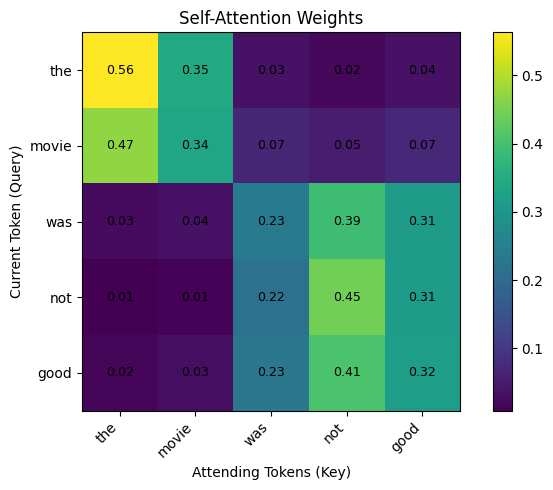

In [ ]:
import matplotlib.pyplot as plt

# attention map을 시각화하는 함수를 정의해봅시다.
def plot_attention_map(attn_weights, x_tokens, y_tokens=None, title="Attention Map"):
    if y_tokens is None:
        y_tokens = x_tokens

    attn = attn_weights.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(attn)

    ax.set_xticks(range(len(x_tokens)))
    ax.set_xticklabels(x_tokens, rotation=45, ha="right")
    ax.set_yticks(range(len(y_tokens)))
    ax.set_yticklabels(y_tokens)

    ax.set_xlabel("Attending Tokens (Key)")
    ax.set_ylabel("Current Token (Query)")
    ax.set_title(title)

    for i in range(attn.shape[0]):
        for j in range(attn.shape[1]):
            ax.text(j, i, f"{attn[i, j]:.2f}", ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

# attention map을 시각화합니다.
plot_attention_map(weights, tokens, title="Self-Attention Weights")

# 3. `nn.MultiheadAttention`

실전에서는 Self-Attention을 직접 계산하지 않고, 보통 `PyTorch가 제공하는 모듈`을 사용합니다.

`MultiheadAttention(MHA)`은 내부적으로 **여러 개의 head**를 사용합니다.

head를 여러 개 사용하여 모델이 **토큰들의 관계를 여러 관점에서 볼 수 있게** 됩니다.

x_batch shape		: torch.Size([1, 5, 4])
attn_output shape	: torch.Size([1, 5, 4])
attn_weights shape	: torch.Size([1, 5, 5])


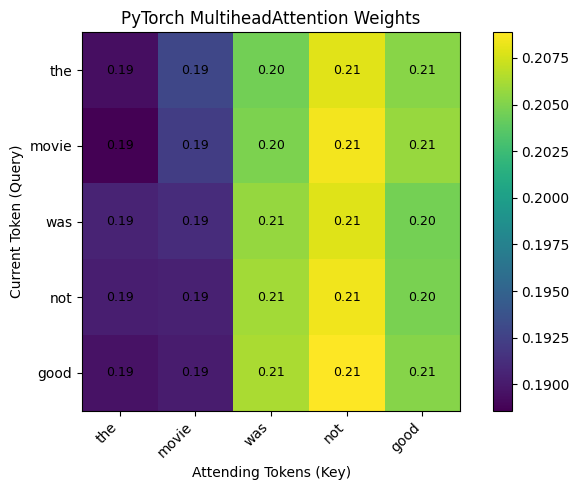

In [ ]:
import torch.nn as nn
# MHA는 배치를 받기 때문에 배치 차원을 추가해야 합니다.
x_batch = X.unsqueeze(0)   # [1, seq_len, d_model]
print("x_batch shape\t\t:", x_batch.shape)

d_model = X.shape[1]
mha = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=2,
    batch_first=True
)

attn_output, attn_weights = mha(x_batch, x_batch, x_batch)   # Q, K, V 값

print("attn_output shape\t:", attn_output.shape)
print("attn_weights shape\t:", attn_weights.shape)

# attention weights를 보기 쉽게 DataFrame으로 만들어서 출력해봅니다.
attn_weights_2d = attn_weights.squeeze(0)
plot_attention_map(attn_weights_2d, tokens, title="PyTorch MultiheadAttention Weights")